In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [2]:
df = pd.read_csv("../swift_burst_data.txt", delimiter= "\t", encoding = "latin1")

In [3]:
df.head(2)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
0,250331C,04:37:40,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,...,NaN,139,NaN,NaN,NaN,NaN,NaN,NaN,BAT: GCN 39959|XRT: GCN 39959; GCN 39960; GCN ...,Brad Cenko
1,250331B,04:19:43,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,...,NaN,317,NaN,White>19.6,NaN,NaN,NaN,NaN,BAT: GCN 39958|XRT: GCN 39958; GCN 39974; GCN ...,Brad Cenko


In [4]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

# EDA and Data Cleaning

### Inspecting data

<Axes: >

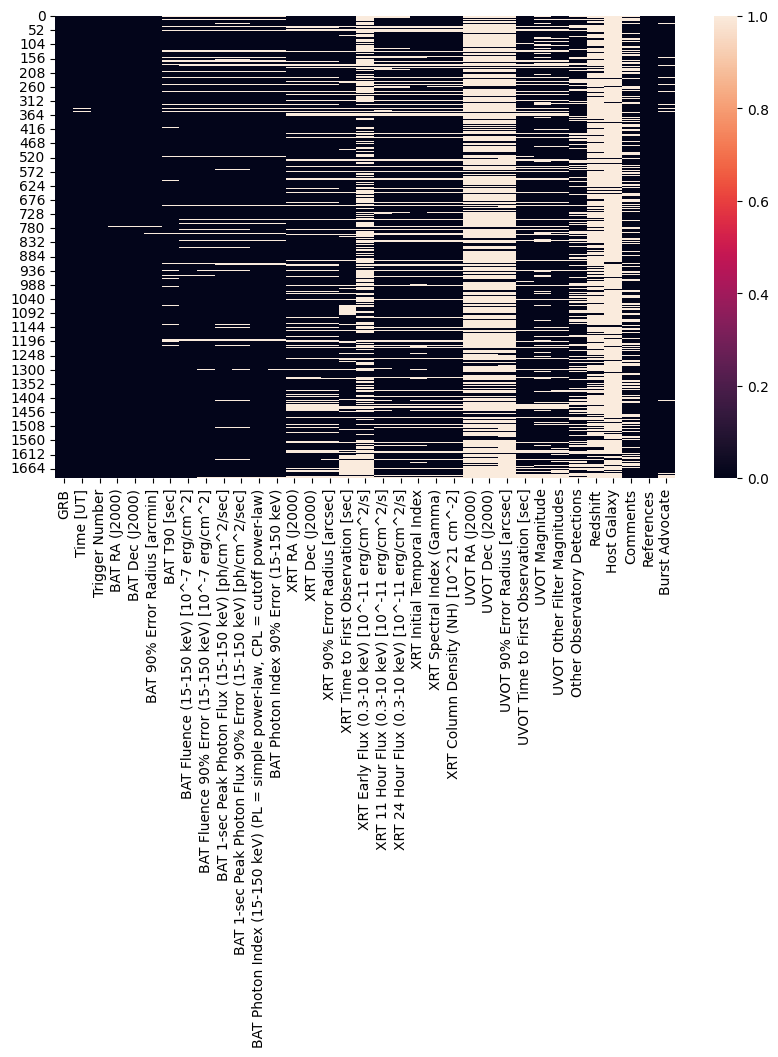

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())

Getting all the columns which are dtype numerical (float)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 35 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1699 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1699 non-null   object 
 3   BAT RA (J2000)                                                                 1698 non-null   float64
 4   BAT Dec (J2000)                                                                1698 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1690 non-null   object 
 6   BAT T90 [sec]           

In [8]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1551.000000,1547.000000,1381.000000,1353.000000,1405.000000,1405.000000
mean,180.874866,2.831430,4.139852,0.313142,1.910913,0.155228,2.062960,5.623895
std,104.353416,41.386243,12.605058,0.324452,0.985266,0.527018,1.286381,10.769524
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015167,1.822810,1.080055
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.589120
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125770,2.171190,5.765250
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [9]:
df.shape

(1699, 35)

### Dealing with missing values

removing features with majority of null values

<Axes: >

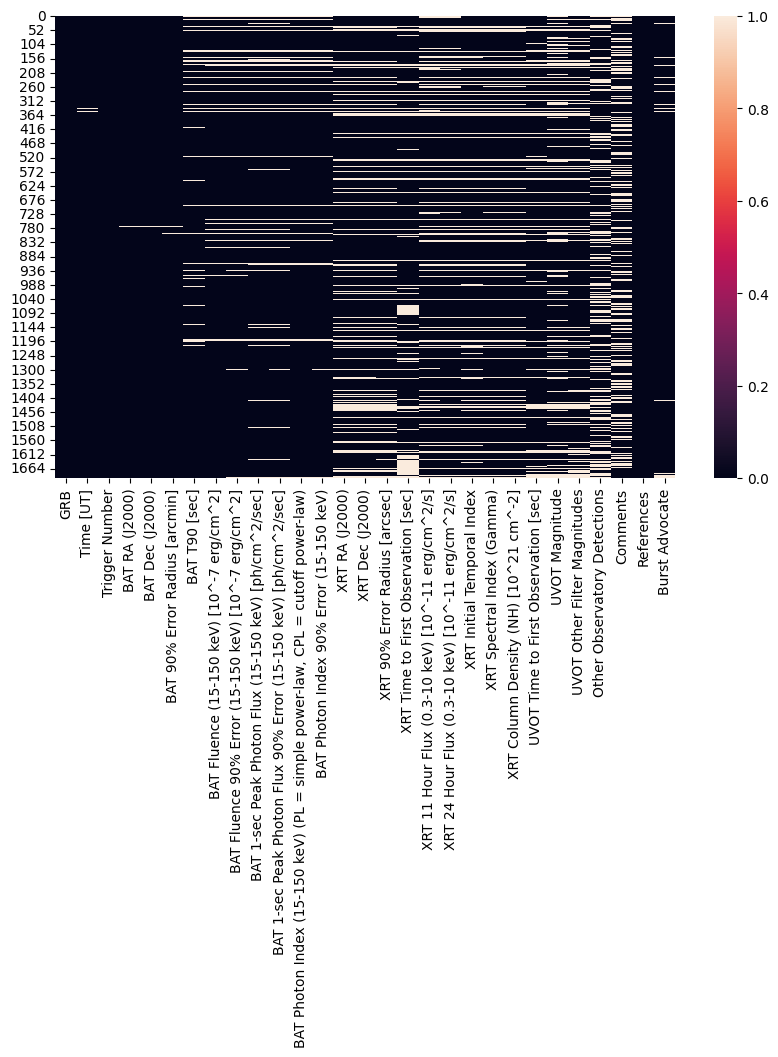

In [10]:
df2 = df.drop(["XRT Early Flux (0.3-10 keV) [10^-11 erg/cm^2/s]", "UVOT RA (J2000)","UVOT Dec (J2000)","UVOT 90% Error Radius [arcsec]","Redshift","Host Galaxy"], axis= 1)
plt.figure(figsize=(10,6))
sns.heatmap(df2.isnull())

Checking values for features that seem to have majority of values as null values:

In [11]:
df["Comments"].isnull().value_counts()        

Comments
False    1127
True      572
Name: count, dtype: int64

In [12]:
df["Other Observatory Detections"].isnull().value_counts()

Other Observatory Detections
False    1202
True      497
Name: count, dtype: int64

In [13]:
df[df["Time [UT]"].isnull()]

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
77,240101A,NaN,1205708,10.2890,8.5400,3.8,15.8,3.3,0.7,0.9,...,NaN,168,V>18.7,B>18.9|U>18.3|UVW1>19.5|UVW2>18.7|White>20.8,NaN,NaN,NaN,UVOT: no detection,BAT: GCN 35448; GCN 35473|XRT: GCN 35448; GCN ...,Brad Cenko
250,210402A,NaN,1040123,198.2650,44.5100,1.2,238.7,86,4,1.6,...,NaN,NaN,V>19.6,B>20.2|U>20.2|UVW1>19.2|UVW2>18.4|White>21.4,"LBT, NOT, Fermi (GBM), MASTER-Net",NaN,NaN,BAT: Due to a ground pass at the time of the G...,BAT: GCN 29743; GCN 29761|XRT: GCN 29743; GCN ...,Kim Page
339,200405B,NaN,Ground Analysis,62.7894,-51.5326,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XRT: Four uncatalogued X-ray sources were dete...,BAT: GCN 27497|XRT: GCN 27500; GCN 27568,Sibasish Laha
340,200325A,NaN,Ground Analysis,31.7203,-31.8160,4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"Fermi (GMB), AGILE, AstroSat, IPN",NaN,NaN,Detected by Fermi GBM (GCN 27434) which trigge...,BAT: GCN 27444,NaN
346,200228A,NaN,Ground Analysis,333.8928,-42.9443,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"Fermi (GBM), AstroSat (CZTI)",NaN,NaN,No XRT or UVOT follow-up will take place due t...,BAT: GCN 27259,NaN
351,200216A,NaN,Ground Analysis,311.4378,-11.6580,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Fermi (GBM),NaN,NaN,No XRT or UVOT follow-up will take place due t...,BAT: GCN 27107|XRT: GCN 27107|UVOT: GCN 27107,NaN
1018,120701A,NaN,525477,80.3380,-58.5310,1.3,13.8,14,1,1.6,...,NaN,89,V>18.8,B>20.3|U_fc=19.16|U>19.9|UVW1>20.6|UVM2>20.7|U...,MPG/ESO (2.2m),NaN,NaN,There was no initial set of GCN Notices nor a ...,"BAT: GCN 13404|XRT: GCN 13406; Evans et al., 2...",Eda Sonbas
1019,120630A,NaN,525451,352.3000,42.4950,2.7,0.6,0.61,0.14,0.7,...,NaN,150,V>19.0,B>20.0|U>20.3|UVW1>19.3|UVM2>19.0|UVW2>19.5,NOT (2.5m),NaN,NaN,There was no initial set of GCN Notices nor a ...,"BAT: GCN 13405|XRT: GCN 13405; Evans et al., 2...",NaN


In [14]:
df2 = df2[df2["Time [UT]"].notnull()]

<Axes: >

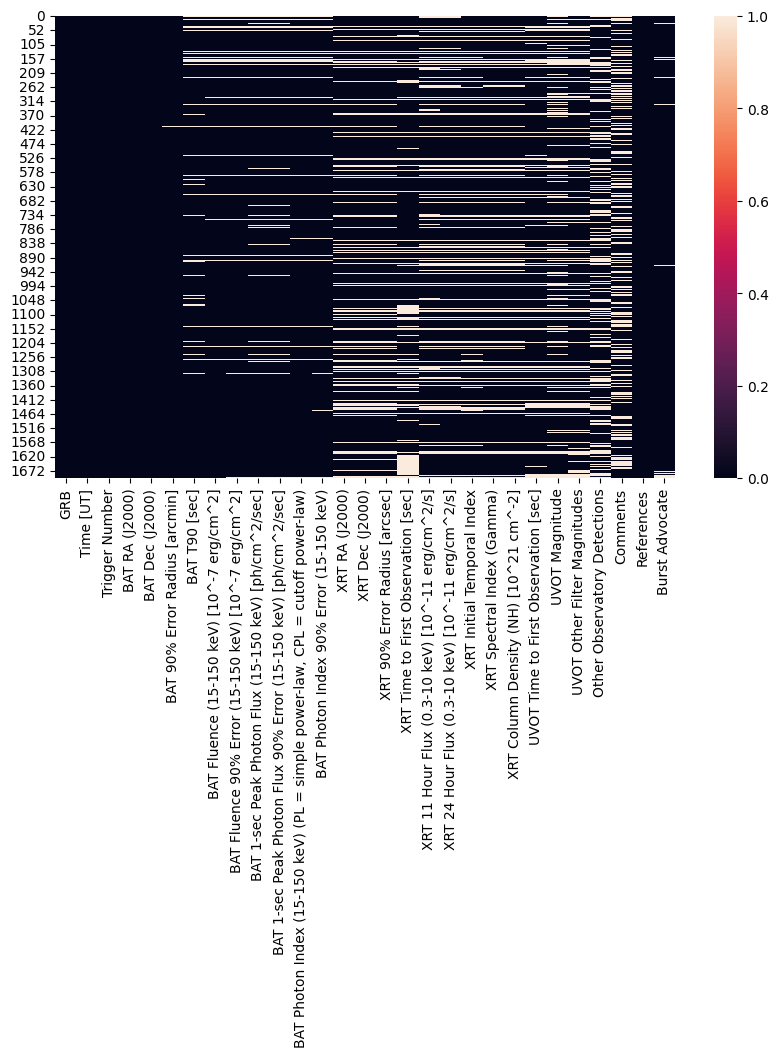

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df2.isnull())

In [16]:
df2.shape

(1691, 29)

In [17]:
df.shape

(1699, 35)

In [18]:
df2.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1690.000000,1690.000000,1547.000000,1543.000000,1378.000000,1349.000000,1401.000000,1401.000000
mean,180.913899,2.904559,4.147453,0.313435,1.910864,0.155572,2.063060,5.632545
std,104.187517,41.387131,12.620449,0.324821,0.986307,0.527755,1.288186,10.783415
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,90.076500,-29.822000,0.800000,0.200000,1.400000,0.015206,1.822810,1.080055
50%,186.046500,3.640500,1.500000,0.200000,1.500000,0.045349,1.995440,2.589120
75%,270.795000,36.076250,3.400000,0.300000,2.000000,0.126028,2.171190,5.768700
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


In [19]:
def missing(feature):   #created a function to determine total number of missing values in each column
    '''
    Determines the number of missing values for a given feature \n
    Parameters : \n
    feature = none 
    '''
    return feature.isnull().value_counts()


In [20]:
type(df2["GRB"])

pandas.core.series.Series

In [21]:
for columns in df2.columns:
    print(missing(df2[columns]))

GRB
False    1691
Name: count, dtype: int64
Time [UT]
False    1691
Name: count, dtype: int64
Trigger Number
False    1691
Name: count, dtype: int64
BAT RA (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT Dec (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT 90% Error Radius [arcmin]
False    1682
True        9
Name: count, dtype: int64
BAT T90 [sec]
False    1570
True      121
Name: count, dtype: int64
BAT Fluence (15-150 keV) [10^-7 erg/cm^2]
False    1592
True       99
Name: count, dtype: int64
BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]
False    1583
True      108
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)
False    1595
True       96
Name: count, dtype: int64


Checking the number of missing values in numerical columns:

In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1691 entries, 0 to 1698
Data columns (total 29 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   GRB                                                                            1691 non-null   object 
 1   Time [UT]                                                                      1691 non-null   object 
 2   Trigger Number                                                                 1691 non-null   object 
 3   BAT RA (J2000)                                                                 1690 non-null   float64
 4   BAT Dec (J2000)                                                                1690 non-null   float64
 5   BAT 90% Error Radius [arcmin]                                                  1682 non-null   object 
 6   BAT T90 [sec]                

#### Getting the number of null values for numerical columns

In [23]:
df2.dtypes

GRB                                                                               object
Time [UT]                                                                         object
Trigger Number                                                                    object
BAT RA (J2000)                                                                   float64
BAT Dec (J2000)                                                                  float64
BAT 90% Error Radius [arcmin]                                                     object
BAT T90 [sec]                                                                     object
BAT Fluence (15-150 keV) [10^-7 erg/cm^2]                                         object
BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]                               object
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]                            float64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]                  float64
BAT Photon Index (15-

In [24]:
dtype_dict = df2.dtypes.to_dict()
list_of_numerical_columns = [x for (x,y) in dtype_dict.items() if y == "float64"]

In [25]:
list_of_numerical_columns

['BAT RA (J2000)',
 'BAT Dec (J2000)',
 'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]',
 'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]',
 'XRT 90% Error Radius [arcsec]',
 'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
 'XRT Spectral Index (Gamma)',
 'XRT Column Density (NH) [10^21 cm^-2]']

In [26]:
for columns in list_of_numerical_columns:
    print(missing(df2[columns]))

BAT RA (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT Dec (J2000)
False    1690
True        1
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
XRT 90% Error Radius [arcsec]
False    1378
True      313
Name: count, dtype: int64
XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]
False    1349
True      342
Name: count, dtype: int64
XRT Spectral Index (Gamma)
False    1401
True      290
Name: count, dtype: int64
XRT Column Density (NH) [10^21 cm^-2]
False    1401
True      290
Name: count, dtype: int64


Checking missing values for numerical columns other than right ascension and declination: 

In [27]:
for columns in list_of_numerical_columns[2:]:
    print(missing(df2[columns]))

BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]
False    1547
True      144
Name: count, dtype: int64
BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]
False    1543
True      148
Name: count, dtype: int64
XRT 90% Error Radius [arcsec]
False    1378
True      313
Name: count, dtype: int64
XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]
False    1349
True      342
Name: count, dtype: int64
XRT Spectral Index (Gamma)
False    1401
True      290
Name: count, dtype: int64
XRT Column Density (NH) [10^21 cm^-2]
False    1401
True      290
Name: count, dtype: int64


In [28]:
df2.head(2)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Comments,References,Burst Advocate
0,250331C,04:37:40,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,...,-2.813,1.652792,9.003795,139,NaN,NaN,NaN,NaN,BAT: GCN 39959|XRT: GCN 39959; GCN 39960; GCN ...,Brad Cenko
1,250331B,04:19:43,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,...,-1.11,2.200000,21.000000,317,NaN,White>19.6,NaN,NaN,BAT: GCN 39958|XRT: GCN 39958; GCN 39974; GCN ...,Brad Cenko


In [29]:
df2.drop("References", axis = 1, inplace= True)

Removing the record with null values as right ascension and declination:

In [30]:
df2[df2["BAT RA (J2000)"].isnull()]

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Comments,Burst Advocate
774,141229A,11:49:02,Ground Analysis|20455,NaN,NaN,NaN,7,15,3,1.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MAXI,"XRT: With the present uncertainties, a secure ...",Jay Cummings


In [31]:
df2 = df2.dropna(subset=["BAT RA (J2000)"])

Checking if there are any reduntant values in GRB feature

In [32]:
df2["GRB"].nunique()

1690

Since all the values in this column are string and unique, we can therefore drop this feature from the dataframe

In [33]:
df2 = df2.drop("GRB", axis = 1)

Converting time feature to int datatype so that it can be used as a predictor for target features with missing values

In [34]:
from datetime import datetime

def time_transform(tstring):

    #converting the string to datetime object
    try:
        time_obj = datetime.strptime(tstring, '%H:%M:%S.%f')   #parsing with fractional seconds

    except ValueError:
        time_obj = datetime.strptime(tstring, '%H:%M:%S')     #parse without fractional seconds
    
    #converting the datetime object to string to int
    return int(time_obj.strftime('%H%M%S'))


df2["Time [UT]"] = df2["Time [UT]"].apply(time_transform)


# time_obj = datetime.strptime(date_string = df2["Time [UT]"], format = '%H:%M:%S')

In [35]:
df2.head(3)

,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],...,XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Comments,Burst Advocate
0,43740,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,...,0.00000187479566,-2.813,1.652792,9.003795,139,NaN,NaN,NaN,NaN,Brad Cenko
1,41943,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,...,NaN,-1.11,2.200000,21.000000,317,NaN,White>19.6,NaN,NaN,Brad Cenko
2,60738,1299776,252.790,-86.870,3,NaN,NaN,NaN,NaN,NaN,...,0.0226783767,-1.117,2.166837,4.471888,3944,V>20.0,B>20.9|U>20.0|UVW1>21.3|UVM2>19.8|White>21.2,"Fermi (GBM), VLT",UVOT: no detection,Brad Cenko


In [36]:
df2 = df2.drop("Burst Advocate", axis = 1)

In [37]:
df2 = df2.drop("Comments", axis = 1)

In [38]:
df2.head(3)

,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],...,XRT Time to First Observation [sec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections
0,43740,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,...,130.90,0.000017,0.00000187479566,-2.813,1.652792,9.003795,139,NaN,NaN,NaN
1,41943,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,...,313.9,NaN,NaN,-1.11,2.200000,21.000000,317,NaN,White>19.6,NaN
2,60738,1299776,252.790,-86.870,3,NaN,NaN,NaN,NaN,NaN,...,73.18,0.054201,0.0226783767,-1.117,2.166837,4.471888,3944,V>20.0,B>20.9|U>20.0|UVW1>21.3|UVM2>19.8|White>21.2,"Fermi (GBM), VLT"


Checking for redundant values in Trigger number feature : 

In [39]:
df2["Trigger Number"].value_counts()

Trigger Number
BAT/GUANO          26
Ground Analysis    11
BATSS               9
BAT/GUNAO           5
Fermi|BAT-GUANO     3
                   ..
736407              1
736432              1
736843              1
737125              1
729293              1
Name: count, Length: 1639, dtype: int64

Since trigger number is also an identifier, we can drop this feature from the dataframe

In [40]:
df2 = df2.drop("Trigger Number", axis = 1)

In [41]:
df2.head(3)

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],"BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)",...,XRT Time to First Observation [sec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections
0,43740,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,NaN,...,130.90,0.000017,0.00000187479566,-2.813,1.652792,9.003795,139,NaN,NaN,NaN
1,41943,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,NaN,...,313.9,NaN,NaN,-1.11,2.200000,21.000000,317,NaN,White>19.6,NaN
2,60738,252.790,-86.870,3,NaN,NaN,NaN,NaN,NaN,NaN,...,73.18,0.054201,0.0226783767,-1.117,2.166837,4.471888,3944,V>20.0,B>20.9|U>20.0|UVW1>21.3|UVM2>19.8|White>21.2,"Fermi (GBM), VLT"


Checking for values in string columns:

In [42]:
def max_char(column):
  
    strcolumn = column.dropna().astype(str)

    return max(strcolumn)

max_char(df2["UVOT Magnitude"])


'n/aV>18.5'

In [43]:
dictionary = {i:max_char(df2[i]) for i in df2.columns}
dictionary

{'Time [UT]': '95934',
 'BAT RA (J2000)': '99.479',
 'BAT Dec (J2000)': '9.9',
 'BAT 90% Error Radius [arcmin]': '~1',
 'BAT T90 [sec]': '~9',
 'BAT Fluence (15-150 keV) [10^-7 erg/cm^2]': '~0.9',
 'BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]': '~0.5',
 'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]': '98.7',
 'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]': '4.6',
 'BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)': '~0.8, PL',
 'BAT Photon Index 90% Error (15-150 keV)': '~0.5',
 'XRT RA (J2000)': '23:55:01.62',
 'XRT Dec (J2000)': '89:11:04.6',
 'XRT 90% Error Radius [arcsec]': '9.3',
 'XRT Time to First Observation [sec]': '~59040',
 'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]': '9.993522e-07',
 'XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]': '<0.0037',
 'XRT Initial Temporal Index': '~0.8',
 'XRT Spectral Index (Gamma)': '9.998',
 'XRT Column Density (NH) [10^21 cm^-2]': '9.99965',
 'UVOT Time to First Obser

In [44]:
df2["Other Observatory Detections"].value_counts()

Other Observatory Detections
Fermi (GBM)                                                                                                                                                                                                                              143
Konus-Wind                                                                                                                                                                                                                                36
Fermi (GBM), Konus-Wind                                                                                                                                                                                                                   16
Konus-Wind, Suzaku                                                                                                                                                                                                                        13
Suzaku                 

Inspecting the UVOT magnitude and UVOT other filters magnitude : 

In [45]:
df2[df2["UVOT Magnitude"].notnull()]["UVOT Magnitude"]

2        V>20.0
4        V>18.9
5        V>18.9
9       V=17.10
10      V=16.89
         ...   
1679     V>21.2
1681    V>19.41
1682     V>20.7
1683     V>19.5
1688     V>17.4
Name: UVOT Magnitude, Length: 1260, dtype: object

Parsing the values of the UVOT filter magnitude feature

In [46]:
def parse_uvot(value):
    '''
    Parses the values of the feature into new columns according to the values\n
    '>' --> no detection\n
    '=' --> detection

    '''
    #setting the default values
    upper_limit = np.nan   
    detection_flag = np.nan

    try:
        if isinstance(value, str):      # for no detection
            if ">" in value:
                upper_limit = value.split(">")[1]
                detection_flag = 0
            elif "=" in value:          # for detection
                upper_limit = value.split("=")[1]
                detection_flag = 1
    except:
        pass

    return pd.Series([upper_limit, detection_flag])   # creating a series of both the values i.e. upper_limit and detection_flag

df2[["UVOT magnitude upper limit", "UVOT detection"]] = df2["UVOT Magnitude"].apply(parse_uvot)

In [47]:
df2.head(2)

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],"BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)",...,XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Initial Temporal Index,XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,UVOT magnitude upper limit,UVOT detection
0,43740,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00000187479566,-2.813,1.652792,9.003795,139,NaN,NaN,NaN,NaN,NaN
1,41943,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-1.11,2.200000,21.000000,317,NaN,White>19.6,NaN,NaN,NaN


In [48]:
df2[["UVOT magnitude upper limit","UVOT detection"]]

,UVOT magnitude upper limit,UVOT detection
0,NaN,NaN
1,NaN,NaN
2,20.0,0.0
3,NaN,NaN
4,18.9,0.0
...,...,...
1694,NaN,NaN
1695,NaN,NaN
1696,NaN,NaN
1697,NaN,NaN


In [49]:
df2.drop("UVOT Magnitude", axis = 1, inplace = True)   # removing the original UVOT magnitude feature

#### Parsing the UVOT other filter magnitudes feature

In [50]:
df2["UVOT Other Filter Magnitudes"]

0                                                     NaN
1                                              White>19.6
2            B>20.9|U>20.0|UVW1>21.3|UVM2>19.8|White>21.2
3                                                     NaN
4       B>19.7|U>20.0|UVW1>19.2|UVM2>19.0|UVW2>19.2|Wh...
                              ...                        
1694                                                  NaN
1695                                                  NaN
1696                                                  NaN
1697                                                  NaN
1698                                                  NaN
Name: UVOT Other Filter Magnitudes, Length: 1690, dtype: object

Since all these values are non detection, therefore there is no need to create a detection flag for this feature

Parsing the UVOT other filter magnitudes into 6 separate features for each filter

In [51]:
def parsing_uvot_other(values):

    diction = {                 # create a default dictionary for each filter with none as default upper limit magnitude values
        "B" : np.nan,
        "U" : np.nan, 
        "UVW1" : np.nan, 
        "UVM2" : np.nan,
        "UVW2" : np.nan,
        "White" : np.nan
    }
    
    if isinstance(values, str):      # check for datatype of the value
        value = values.split("|")      # split the value for different filters to create a list

        #create a dictionary of each filter as filter name as key and non-detection upper limit as its value, for each column value 
        for part in value:
            if part.split(">")[0] in diction:
                diction[part.split(">")[0]] = float(part.split(">")[1])
        return diction
    else:
        return diction

list_of_dict = df2["UVOT Other Filter Magnitudes"].apply(parsing_uvot_other).tolist()    # list of dictionaries

parsed_dataframe = pd.DataFrame(list_of_dict)    # dataframe created from the list of the dictionaries
parsed_dataframe


,B,U,UVW1,UVM2,UVW2,White
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,19.6
2,20.9,20.0,21.3,19.8,NaN,21.2
3,NaN,NaN,NaN,NaN,NaN,NaN
4,19.7,20.0,19.2,19.0,19.2,20.9
...,...,...,...,...,...,...
1685,NaN,NaN,NaN,NaN,NaN,NaN
1686,NaN,NaN,NaN,NaN,NaN,NaN
1687,NaN,NaN,NaN,NaN,NaN,NaN
1688,NaN,NaN,NaN,NaN,NaN,NaN


concating the dataframe to our GRB dataframe

In [52]:
df2 = pd.concat([df2, parsed_dataframe], axis = 1)    # concated the new columns into the grb dataframe

In [53]:
df2.head(1)

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],"BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)",...,UVOT Other Filter Magnitudes,Other Observatory Detections,UVOT magnitude upper limit,UVOT detection,B,U,UVW1,UVM2,UVW2,White
0,43740.0,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df2

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],"BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)",...,UVOT Other Filter Magnitudes,Other Observatory Detections,UVOT magnitude upper limit,UVOT detection,B,U,UVW1,UVM2,UVW2,White
0,43740.0,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,41943.0,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,NaN,...,White>19.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.6
2,60738.0,252.790,-86.870,3,NaN,NaN,NaN,NaN,NaN,NaN,...,B>20.9|U>20.0|UVW1>21.3|UVM2>19.8|White>21.2,"Fermi (GBM), VLT",20.0,0.0,20.9,20.0,21.3,19.8,NaN,21.2
3,73004.0,248.209,61.610,2.2,91.008,76,5,2.1,0.7,"1.28, PL",...,NaN,Fermi (GMB),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,160612.0,106.775,7.197,1.5,0.62,1.5,0.2,1.4,0.2,"0.65, PL",...,B>19.7|U>20.0|UVW1>19.2|UVM2>19.0|UVW2>19.2|Wh...,"AstroSat CZTI, Konus-Wind",18.9,0.0,19.7,20.0,19.2,19.0,19.2,20.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,19.8,20.3,19.2,NaN,19.8,21.2
351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,20.6,20.7,20.1,19.5,20.3,21.7
774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,20.1,NaN,18.7,NaN,19.0,NaN
1018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,20.3,21.5,22.1,NaN


In [55]:
df2.drop("UVOT Other Filter Magnitudes", axis = 1, inplace = True)

In [56]:
df2.drop("Other Observatory Detections", axis = 1, inplace = True)

#### Parsing and encoding the BAT Photon index feature

In [57]:
df2["BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)"]

0            NaN
1            NaN
2            NaN
3       1.28, PL
4       0.65, PL
          ...   
346          NaN
351          NaN
774          NaN
1018         NaN
1019         NaN
Name: BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law), Length: 1699, dtype: object

In [58]:
def parse_photon_index(value):

    #setting the default values for magnitude, pl and cpl variables
    magnitude = np.nan
    pl = 0
    cpl = 0

    if isinstance(value, str):
        parts = value.split(",")
        if len(parts) == 2:
            magnitude = float(parts[0].strip().replace("~",""))
            model_type = parts[1].strip()
            if model_type == "PL":
                pl = 1
            elif model_type == "CPL":
                cpl = 1

    return pd.Series([magnitude, pl, cpl])

df2[["BAT_Photon_Index (15-150 keV)", "PL", "CPL"]] = df2["BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)"].apply(parse_photon_index)


In [59]:
df2

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],"BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)",...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
0,43740.0,80.993,33.029,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,41943.0,71.381,43.805,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.6,NaN,0.0,0.0
2,60738.0,252.790,-86.870,3,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,20.9,20.0,21.3,19.8,NaN,21.2,NaN,0.0,0.0
3,73004.0,248.209,61.610,2.2,91.008,76,5,2.1,0.7,"1.28, PL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.28,1.0,0.0
4,160612.0,106.775,7.197,1.5,0.62,1.5,0.2,1.4,0.2,"0.65, PL",...,0.0,19.7,20.0,19.2,19.0,19.2,20.9,0.65,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,19.8,20.3,19.2,NaN,19.8,21.2,NaN,0.0,0.0
351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,20.6,20.7,20.1,19.5,20.3,21.7,NaN,0.0,0.0
774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,20.1,NaN,18.7,NaN,19.0,NaN,NaN,0.0,0.0
1018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,20.3,21.5,22.1,NaN,NaN,0.0,0.0


In [60]:
df2.drop("BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)", axis = 1, inplace = True)

##### Inspecting other features

In [61]:
df2['BAT 90% Error Radius [arcmin]']

0         3
1         3
2         3
3       2.2
4       1.5
       ... 
346     NaN
351     NaN
774     NaN
1018    NaN
1019    NaN
Name: BAT 90% Error Radius [arcmin], Length: 1699, dtype: object

Cleaning features with approximate values

In [62]:
def clean_column(value):

    if isinstance(value, str):
        value = value.strip().replace("~","")
        try:
            return float(value)
        except:
            return np.nan
        
    elif isinstance(value, (float, int)):
        return value
    else:
        return np.nan



In [63]:
df2['BAT 90% Error Radius [arcmin]'] = df2['BAT 90% Error Radius [arcmin]'].apply(clean_column)

In [64]:
df2['BAT T90 [sec]'] = df2['BAT T90 [sec]'].apply(clean_column)

In [65]:
df2['BAT Fluence (15-150 keV) [10^-7 erg/cm^2]'] = df2['BAT Fluence (15-150 keV) [10^-7 erg/cm^2]'].apply(clean_column)

df2['BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]'] = df2['BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]'].apply(clean_column)

df2['BAT Photon Index 90% Error (15-150 keV)'] = df2['BAT Photon Index 90% Error (15-150 keV)'].apply(clean_column)

df2['XRT Time to First Observation [sec]'] = df2['XRT Time to First Observation [sec]'].apply(clean_column)

df2['XRT Initial Temporal Index'] = df2['XRT Initial Temporal Index'].apply(clean_column)

df2['UVOT Time to First Observation [sec]'] = df2['UVOT Time to First Observation [sec]'].apply(clean_column)

In [66]:
df2.head(10)

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
0,43740.0,80.993,33.029,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,41943.0,71.381,43.805,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.6,NaN,0.0,0.0
2,60738.0,252.790,-86.870,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,20.90,20.0,21.30,19.80,NaN,21.2,NaN,0.0,0.0
3,73004.0,248.209,61.610,2.2,91.008,76.0,5.0,2.1,0.7,0.12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.28,1.0,0.0
4,160612.0,106.775,7.197,1.5,0.620,1.5,0.2,1.4,0.2,0.19,...,0.0,19.70,20.0,19.20,19.00,19.20,20.9,0.65,1.0,0.0
5,4238.0,295.100,21.055,1.8,6.210,6.7,0.8,3.2,0.5,0.19,...,0.0,20.00,19.4,19.30,19.20,19.30,20.6,1.61,1.0,0.0
6,132417.0,29.510,-42.404,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,18.84,19.8,19.99,19.85,20.24,20.5,NaN,0.0,0.0
7,163008.0,354.724,-47.998,1.1,11.440,89.0,3.0,35.9,1.6,0.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87,0.0,1.0
8,193913.0,306.134,-41.481,1.0,110.460,65.0,2.0,10.4,0.5,0.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.60,1.0,0.0
9,33437.0,59.476,-15.137,1.9,1.800,3.9,0.6,2.9,0.5,0.23,...,1.0,18.70,NaN,19.00,18.60,18.70,NaN,1.43,1.0,0.0


In [67]:
df2['XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]']

0       0.00000187479566
1                    NaN
2           0.0226783767
3                    NaN
4        0.0000007994484
              ...       
346                  NaN
351                  NaN
774                  NaN
1018                 NaN
1019                 NaN
Name: XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s], Length: 1699, dtype: object

In [68]:
not_null_list = df2[df2['XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]'].notna()]['XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]']
for i in not_null_list:
    if "<" in i:
        print(i)

<0.0037
<0.001


In [69]:
def clean_lesser(value):

    if isinstance(value, str):
        value = value.strip().replace("<","")
        try:
            return float(value)
        except:
            return np.nan
        
    elif isinstance(value, (float, int)):
        return value
    else:
        return np.nan
    
df2['XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]'] = df2['XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]'].apply(clean_lesser)

In [70]:
df2.head(10)

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
0,43740.0,80.993,33.029,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,41943.0,71.381,43.805,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.6,NaN,0.0,0.0
2,60738.0,252.790,-86.870,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,20.90,20.0,21.30,19.80,NaN,21.2,NaN,0.0,0.0
3,73004.0,248.209,61.610,2.2,91.008,76.0,5.0,2.1,0.7,0.12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.28,1.0,0.0
4,160612.0,106.775,7.197,1.5,0.620,1.5,0.2,1.4,0.2,0.19,...,0.0,19.70,20.0,19.20,19.00,19.20,20.9,0.65,1.0,0.0
5,4238.0,295.100,21.055,1.8,6.210,6.7,0.8,3.2,0.5,0.19,...,0.0,20.00,19.4,19.30,19.20,19.30,20.6,1.61,1.0,0.0
6,132417.0,29.510,-42.404,3.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,18.84,19.8,19.99,19.85,20.24,20.5,NaN,0.0,0.0
7,163008.0,354.724,-47.998,1.1,11.440,89.0,3.0,35.9,1.6,0.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87,0.0,1.0
8,193913.0,306.134,-41.481,1.0,110.460,65.0,2.0,10.4,0.5,0.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.60,1.0,0.0
9,33437.0,59.476,-15.137,1.9,1.800,3.9,0.6,2.9,0.5,0.23,...,1.0,18.70,NaN,19.00,18.60,18.70,NaN,1.43,1.0,0.0


<Axes: >

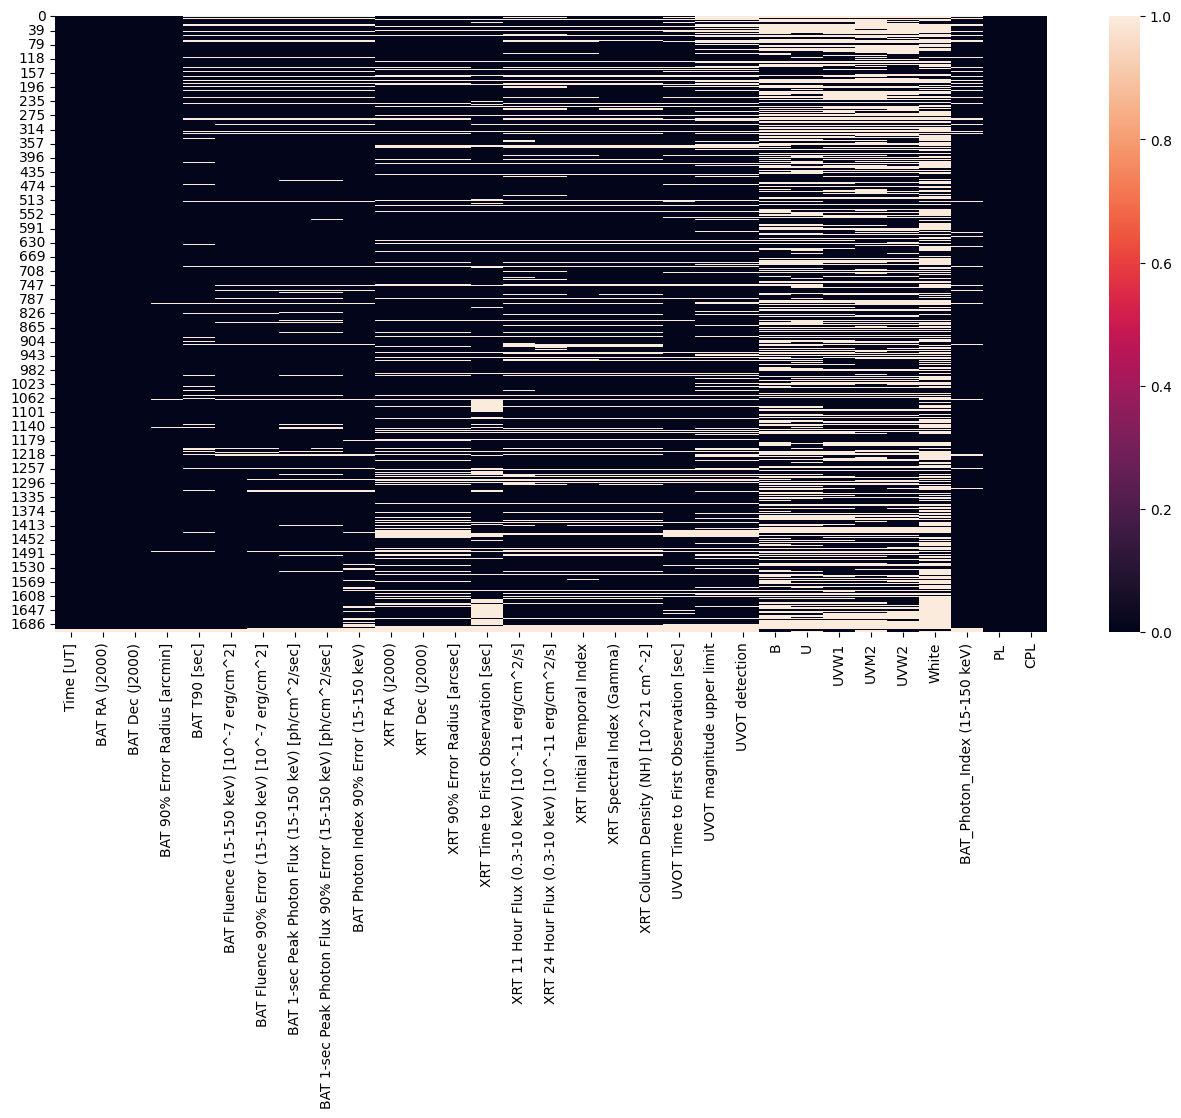

In [71]:
plt.figure(figsize = (16,8))
sns.heatmap(df2.isnull())

In [72]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1699 entries, 0 to 1019
Data columns (total 31 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Time [UT]                                                        1690 non-null   float64
 1   BAT RA (J2000)                                                   1690 non-null   float64
 2   BAT Dec (J2000)                                                  1690 non-null   float64
 3   BAT 90% Error Radius [arcmin]                                    1682 non-null   float64
 4   BAT T90 [sec]                                                    1559 non-null   float64
 5   BAT Fluence (15-150 keV) [10^-7 erg/cm^2]                        1590 non-null   float64
 6   BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]              1582 non-null   float64
 7   BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^

In [73]:
df2.describe()

,Time [UT],BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
count,1690.000000,1690.000000,1690.000000,1682.000000,1559.000000,1590.000000,1582.000000,1546.00000,1542.000000,1551.000000,...,1260.000000,906.000000,944.000000,1017.000000,989.000000,1035.000000,733.000000,1583.000000,1699.000000,1699.000000
mean,113138.457988,180.913899,2.904559,1.801510,72.750845,40.474780,1.605885,4.14936,0.313314,0.228947,...,0.243651,20.117826,22.421141,19.908476,19.930718,20.426338,21.292701,1.510279,0.792231,0.138905
std,69895.342025,104.187517,41.387131,0.832924,119.406536,125.885422,1.986039,12.62431,0.324892,0.226352,...,0.429455,3.342110,63.765797,1.096309,1.298831,7.827944,6.911370,0.494864,0.405830,0.345949
min,59.000000,0.127000,-89.029000,0.460000,0.018000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,1.300000,2.300000,10.930000,2.600000,17.000000,10.800000,-1.100000,0.000000,0.000000
25%,51534.750000,90.076500,-29.822000,1.100000,10.420000,4.700000,0.592500,0.80000,0.200000,0.110000,...,0.000000,19.600000,19.700000,19.220000,19.300000,19.405000,20.600000,1.235000,1.000000,0.000000
50%,111775.500000,186.046500,3.640500,1.700000,37.550000,13.000000,1.000000,1.50000,0.200000,0.190000,...,0.000000,20.205000,20.205000,20.000000,20.000000,20.100000,21.100000,1.530000,1.000000,0.000000
75%,173341.500000,270.795000,36.076250,2.200000,89.550000,36.000000,2.000000,3.40000,0.300000,0.270000,...,0.000000,20.830000,20.700000,20.600000,20.700000,20.800000,21.600000,1.820000,1.000000,0.000000
max,235925.000000,358.751000,89.180000,10.000000,2100.000000,3100.000000,30.000000,331.00000,4.600000,2.560000,...,1.000000,99.000000,1971.000000,29.000000,29.380000,210.300000,206.000000,3.300000,1.000000,1.000000


Dropping the right ascension and declination coordinates since they are not inherently meaningful to the ML model, they are just sky coordinates which are not correlated with the burst type

In [74]:
df2.drop(["BAT RA (J2000)", "BAT Dec (J2000)", "XRT RA (J2000)", "XRT Dec (J2000)"], axis = 1, inplace = True)

In [75]:
print(df2["U"].notnull().value_counts())
print(df2["B"].notnull().value_counts())
print(df2["UVW1"].notnull().value_counts())
print(df2["UVM2"].notnull().value_counts())
print(df2["UVW2"].notnull().value_counts())
print(df2["White"].notnull().value_counts())

U
True     944
False    755
Name: count, dtype: int64
B
True     906
False    793
Name: count, dtype: int64
UVW1
True     1017
False     682
Name: count, dtype: int64
UVM2
True     989
False    710
Name: count, dtype: int64
UVW2
True     1035
False     664
Name: count, dtype: int64
White
False    966
True     733
Name: count, dtype: int64


In [76]:
max(df2["U"])

nan

In [77]:
df2["U"].max()

np.float64(1971.0)

In [78]:
df2[df2["U"] == 1971]

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
396,60208.0,2.0,5.6,2.8,0.4,1.1,0.2,0.24,3.1,47.0,...,0.0,18.98,1971.0,17.44,NaN,18.09,NaN,1.36,1.0,0.0


In [79]:
df2[df2["B"] == 99]

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
478,134940.0,1.3,486.4,58.0,3.0,1.4,0.2,0.1,1.4,112.24,...,0.0,99.0,21.8,21.2,21.0,20.1,NaN,1.91,1.0,0.0


Setting the limits for each magnitude filter according to the UVOT instrument: 

In [80]:
uvot_limits = {
    'White': 25.0,
    'B': 23.0,
    'U': 23.0,
    'UVW1': 23.5,
    'UVM2': 23.5,
    'UVW2': 24.0
}


In [81]:
df2["White"] = df2["White"].fillna(uvot_limits["White"] + 1)
df2["B"] = df2["B"].fillna(uvot_limits["B"] + 1)
df2["U"] = df2["U"].fillna(uvot_limits["U"] + 1)
df2["UVW1"] = df2["UVW1"].fillna(uvot_limits["UVW1"] + 1)
df2["UVM2"] = df2["UVM2"].fillna(uvot_limits["UVM2"] + 1)
df2["UVW2"] = df2["UVW2"].fillna(uvot_limits["UVW2"] + 1)

In [82]:
df2.head(10)

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
0,43740.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.2,130.90,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,NaN,0.0,0.0
1,41943.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.6,313.90,...,NaN,24.00,24.0,24.50,24.50,25.00,19.6,NaN,0.0,0.0
2,60738.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.7,73.18,...,0.0,20.90,20.0,21.30,19.80,25.00,21.2,NaN,0.0,0.0
3,73004.0,2.2,91.008,76.0,5.0,2.1,0.7,0.12,3.6,12100.00,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,1.28,1.0,0.0
4,160612.0,1.5,0.620,1.5,0.2,1.4,0.2,0.19,2.5,72.60,...,0.0,19.70,20.0,19.20,19.00,19.20,20.9,0.65,1.0,0.0
5,4238.0,1.8,6.210,6.7,0.8,3.2,0.5,0.19,2.6,134.00,...,0.0,20.00,19.4,19.30,19.20,19.30,20.6,1.61,1.0,0.0
6,132417.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.2,135.42,...,NaN,18.84,19.8,19.99,19.85,20.24,20.5,NaN,0.0,0.0
7,163008.0,1.1,11.440,89.0,3.0,35.9,1.6,0.24,NaN,NaN,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,0.87,0.0,1.0
8,193913.0,1.0,110.460,65.0,2.0,10.4,0.5,0.07,NaN,NaN,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,1.60,1.0,0.0
9,33437.0,1.9,1.800,3.9,0.6,2.9,0.5,0.23,2.5,122.92,...,1.0,18.70,24.0,19.00,18.60,18.70,26.0,1.43,1.0,0.0


<Axes: >

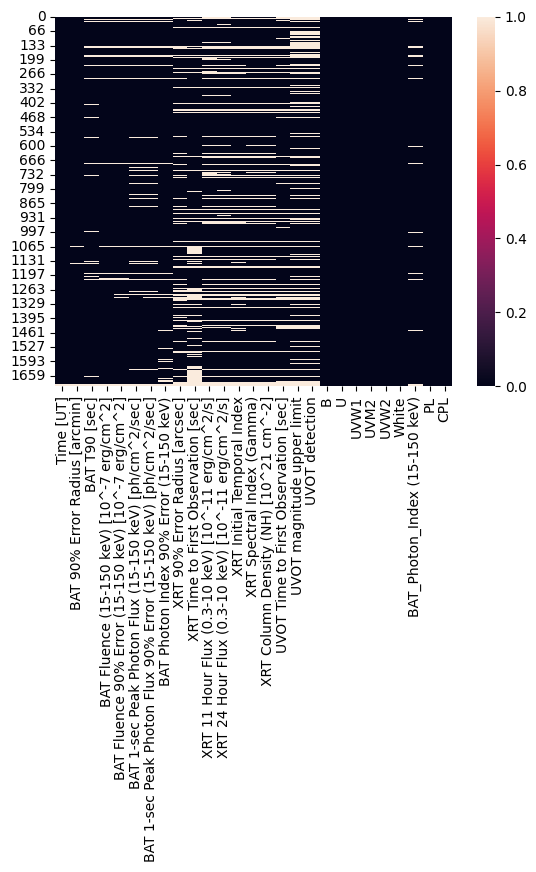

In [83]:
sns.heatmap(df2.isnull())

In [84]:
df2.describe()

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
count,1690.000000,1682.000000,1559.000000,1590.000000,1582.000000,1546.00000,1542.000000,1551.000000,1377.000000,1.351000e+03,...,1260.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1583.000000,1699.000000,1699.000000
mean,113138.457988,1.801510,72.750845,40.474780,1.605885,4.14936,0.313314,0.228947,1.908838,9.892630e+03,...,0.243651,21.929812,23.122753,21.751572,21.840188,22.213808,23.969129,1.510279,0.792231,0.138905
std,69895.342025,0.832924,119.406536,125.885422,1.986039,12.62431,0.324892,0.226352,0.983794,5.237618e+04,...,0.429455,3.115540,47.526301,2.405775,2.462397,6.503670,5.102042,0.494864,0.405830,0.345949
min,59.000000,0.460000,0.018000,0.000000,0.000000,0.00000,0.000000,0.000000,1.400000,3.095000e+01,...,0.000000,1.300000,2.300000,10.930000,2.600000,17.000000,10.800000,-1.100000,0.000000,0.000000
25%,51534.750000,1.100000,10.420000,4.700000,0.592500,0.80000,0.200000,0.110000,1.400000,7.938500e+01,...,0.000000,20.200000,20.200000,19.715000,19.800000,19.900000,21.200000,1.235000,1.000000,0.000000
50%,111775.500000,1.700000,37.550000,13.000000,1.000000,1.50000,0.200000,0.190000,1.500000,1.050000e+02,...,0.000000,21.600000,21.200000,20.900000,21.100000,21.040000,26.000000,1.530000,1.000000,0.000000
75%,173341.500000,2.200000,89.550000,36.000000,2.000000,3.40000,0.300000,0.270000,2.000000,1.567750e+02,...,0.000000,24.000000,24.000000,24.500000,24.500000,25.000000,26.000000,1.820000,1.000000,0.000000
max,235925.000000,10.000000,2100.000000,3100.000000,30.000000,331.00000,4.600000,2.560000,15.000000,1.309800e+06,...,1.000000,99.000000,1971.000000,29.000000,29.380000,210.300000,206.000000,3.300000,1.000000,1.000000


Looking for the colunm with non numerical values

In [85]:
df2.describe().columns

Index(['Time [UT]', 'BAT 90% Error Radius [arcmin]', 'BAT T90 [sec]',
       'BAT Fluence (15-150 keV) [10^-7 erg/cm^2]',
       'BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]',
       'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]',
       'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]',
       'BAT Photon Index 90% Error (15-150 keV)',
       'XRT 90% Error Radius [arcsec]', 'XRT Time to First Observation [sec]',
       'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
       'XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
       'XRT Initial Temporal Index', 'XRT Spectral Index (Gamma)',
       'XRT Column Density (NH) [10^21 cm^-2]',
       'UVOT Time to First Observation [sec]', 'UVOT detection', 'B', 'U',
       'UVW1', 'UVM2', 'UVW2', 'White', 'BAT_Photon_Index (15-150 keV)', 'PL',
       'CPL'],
      dtype='object')

In [86]:
df2.columns

Index(['Time [UT]', 'BAT 90% Error Radius [arcmin]', 'BAT T90 [sec]',
       'BAT Fluence (15-150 keV) [10^-7 erg/cm^2]',
       'BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]',
       'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]',
       'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]',
       'BAT Photon Index 90% Error (15-150 keV)',
       'XRT 90% Error Radius [arcsec]', 'XRT Time to First Observation [sec]',
       'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
       'XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]',
       'XRT Initial Temporal Index', 'XRT Spectral Index (Gamma)',
       'XRT Column Density (NH) [10^21 cm^-2]',
       'UVOT Time to First Observation [sec]', 'UVOT magnitude upper limit',
       'UVOT detection', 'B', 'U', 'UVW1', 'UVM2', 'UVW2', 'White',
       'BAT_Photon_Index (15-150 keV)', 'PL', 'CPL'],
      dtype='object')

In [87]:
for i in df2.columns:
    if i not in df2.describe().columns:
        print(i)



UVOT magnitude upper limit


In [88]:
def floaty(value):
    return float(value)

df2["UVOT magnitude upper limit"] = df2["UVOT magnitude upper limit"].apply(floaty)

In [89]:
df2.describe()

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
count,1690.000000,1682.000000,1559.000000,1590.000000,1582.000000,1546.00000,1542.000000,1551.000000,1377.000000,1.351000e+03,...,1260.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1583.000000,1699.000000,1699.000000
mean,113138.457988,1.801510,72.750845,40.474780,1.605885,4.14936,0.313314,0.228947,1.908838,9.892630e+03,...,0.243651,21.929812,23.122753,21.751572,21.840188,22.213808,23.969129,1.510279,0.792231,0.138905
std,69895.342025,0.832924,119.406536,125.885422,1.986039,12.62431,0.324892,0.226352,0.983794,5.237618e+04,...,0.429455,3.115540,47.526301,2.405775,2.462397,6.503670,5.102042,0.494864,0.405830,0.345949
min,59.000000,0.460000,0.018000,0.000000,0.000000,0.00000,0.000000,0.000000,1.400000,3.095000e+01,...,0.000000,1.300000,2.300000,10.930000,2.600000,17.000000,10.800000,-1.100000,0.000000,0.000000
25%,51534.750000,1.100000,10.420000,4.700000,0.592500,0.80000,0.200000,0.110000,1.400000,7.938500e+01,...,0.000000,20.200000,20.200000,19.715000,19.800000,19.900000,21.200000,1.235000,1.000000,0.000000
50%,111775.500000,1.700000,37.550000,13.000000,1.000000,1.50000,0.200000,0.190000,1.500000,1.050000e+02,...,0.000000,21.600000,21.200000,20.900000,21.100000,21.040000,26.000000,1.530000,1.000000,0.000000
75%,173341.500000,2.200000,89.550000,36.000000,2.000000,3.40000,0.300000,0.270000,2.000000,1.567750e+02,...,0.000000,24.000000,24.000000,24.500000,24.500000,25.000000,26.000000,1.820000,1.000000,0.000000
max,235925.000000,10.000000,2100.000000,3100.000000,30.000000,331.00000,4.600000,2.560000,15.000000,1.309800e+06,...,1.000000,99.000000,1971.000000,29.000000,29.380000,210.300000,206.000000,3.300000,1.000000,1.000000


In [90]:
df2.head(10)

,Time [UT],BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],BAT Photon Index 90% Error (15-150 keV),XRT 90% Error Radius [arcsec],XRT Time to First Observation [sec],...,UVOT detection,B,U,UVW1,UVM2,UVW2,White,BAT_Photon_Index (15-150 keV),PL,CPL
0,43740.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.2,130.90,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,NaN,0.0,0.0
1,41943.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,3.6,313.90,...,NaN,24.00,24.0,24.50,24.50,25.00,19.6,NaN,0.0,0.0
2,60738.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.7,73.18,...,0.0,20.90,20.0,21.30,19.80,25.00,21.2,NaN,0.0,0.0
3,73004.0,2.2,91.008,76.0,5.0,2.1,0.7,0.12,3.6,12100.00,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,1.28,1.0,0.0
4,160612.0,1.5,0.620,1.5,0.2,1.4,0.2,0.19,2.5,72.60,...,0.0,19.70,20.0,19.20,19.00,19.20,20.9,0.65,1.0,0.0
5,4238.0,1.8,6.210,6.7,0.8,3.2,0.5,0.19,2.6,134.00,...,0.0,20.00,19.4,19.30,19.20,19.30,20.6,1.61,1.0,0.0
6,132417.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.2,135.42,...,NaN,18.84,19.8,19.99,19.85,20.24,20.5,NaN,0.0,0.0
7,163008.0,1.1,11.440,89.0,3.0,35.9,1.6,0.24,NaN,NaN,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,0.87,0.0,1.0
8,193913.0,1.0,110.460,65.0,2.0,10.4,0.5,0.07,NaN,NaN,...,NaN,24.00,24.0,24.50,24.50,25.00,26.0,1.60,1.0,0.0
9,33437.0,1.9,1.800,3.9,0.6,2.9,0.5,0.23,2.5,122.92,...,1.0,18.70,24.0,19.00,18.60,18.70,26.0,1.43,1.0,0.0


In [ ]:
a = "test"